<a href="https://colab.research.google.com/github/Abdallah-Osama-cpp/heart-disease-prediction/blob/main/Copy_of_Heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import cell

In [ ]:
# 1. Data Manipulation and Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Data Preprocessing and Splitting
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# 3. Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.svm import SVC
# 4. Model Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    classification_report
)

In [185]:
df = pd.read_csv('/content/train_data.csv') # train data
dt = pd.read_csv('/content/test_data.csv')  # test data

**DATA EXPLORE**

In [186]:
df.head(10)

,id,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,1,70.0,Female,4,130,322,0,2,109,0,2.4,2,3,3,Private,formerly smoked,Yes
1,2,67.0,Male,3,115,564,0,2,160,0,1.6,2,0,7,Self-employed,never smoked,No
2,3,57.0,Female,2,124,261,0,0,141,0,0.3,1,0,7,Private,never smoked,Yes
3,4,64.0,Female,4,128,263,0,0,105,1,0.2,2,1,7,Private,smokes,No
4,5,74.0,Male,2,120,269,0,2,121,1,0.2,1,1,3,Self-employed,never smoked,No
5,6,65.0,Female,4,120,177,0,0,140,0,0.4,1,0,7,Private,formerly smoked,No
6,7,56.0,Female,3,130,256,1,2,142,1,0.6,2,1,6,Private,never smoked,Yes
7,8,59.0,Female,4,110,239,0,2,142,1,1.2,2,1,7,Private,never smoked,Yes
8,9,60.0,Female,4,140,293,0,2,170,0,1.2,2,2,7,Private,Unknown,Yes
9,10,63.0,Male,4,150,407,0,2,154,0,4.0,2,3,7,Private,Unknown,Yes


In [187]:
dt.head(10)

,id,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,225,41.0,Male,2,130,204,0,2,172,0,1.4,1,0,3,Private,smokes,No
1,226,63.0,Male,3,135,252,0,2,172,0,0.0,1,0,3,Self-employed,never smoked,No
2,227,51.0,Female,3,94,227,0,0,154,1,0.0,1,1,7,Private,smokes,No
3,228,54.0,Female,3,120,258,0,2,147,0,0.4,2,0,7,Self-employed,smokes,No
4,229,44.0,Female,2,120,220,0,0,170,0,0.0,1,0,3,Govt_job,never smoked,No
5,230,54.0,Female,4,110,239,0,0,126,1,2.8,2,1,7,Private,smokes,Yes
6,231,65.0,Female,4,135,254,0,2,127,0,2.8,2,1,7,Private,never smoked,Yes
7,232,57.0,Female,3,150,168,0,0,174,0,1.6,1,0,3,Govt_job,formerly smoked,No
8,233,63.0,Female,4,130,330,1,2,132,1,1.8,1,3,7,Govt_job,smokes,Yes
9,235,35.0,Male,4,138,183,0,0,182,0,1.4,1,0,3,Private,smokes,No


In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       224 non-null    int64  
 1   Age                      220 non-null    float64
 2   Gender                   218 non-null    object 
 3   Chest pain type          224 non-null    int64  
 4   BP                       224 non-null    int64  
 5   Cholesterol              224 non-null    int64  
 6   FBS over 120             224 non-null    int64  
 7   EKG results              224 non-null    int64  
 8   Max HR                   224 non-null    int64  
 9   Exercise angina          224 non-null    int64  
 10  ST depression            224 non-null    float64
 11  Slope of ST              224 non-null    int64  
 12  Number of vessels fluro  224 non-null    int64  
 13  Thallium                 224 non-null    int64  
 14  work_type                2

In [189]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       56 non-null     int64  
 1   Age                      54 non-null     float64
 2   Gender                   56 non-null     object 
 3   Chest pain type          56 non-null     int64  
 4   BP                       56 non-null     int64  
 5   Cholesterol              56 non-null     int64  
 6   FBS over 120             56 non-null     int64  
 7   EKG results              56 non-null     int64  
 8   Max HR                   56 non-null     int64  
 9   Exercise angina          56 non-null     int64  
 10  ST depression            56 non-null     float64
 11  Slope of ST              56 non-null     int64  
 12  Number of vessels fluro  56 non-null     int64  
 13  Thallium                 56 non-null     int64  
 14  work_type                54 

In [190]:
df.describe()

,id,Age,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,224.000000,220.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000
mean,112.138393,54.550000,3.187500,130.700893,248.044643,0.151786,1.026786,149.245536,0.357143,1.025446,1.602679,0.696429,4.633929
std,64.671738,9.266833,0.961419,18.021034,51.895011,0.359617,0.997394,23.834396,0.480231,1.121668,0.626895,0.940749,1.936182
min,1.000000,29.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,56.750000,47.750000,3.000000,120.000000,212.000000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,112.500000,55.000000,3.000000,130.000000,242.500000,0.000000,2.000000,154.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,168.250000,61.250000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.800000,2.000000,1.000000,7.000000
max,224.000000,77.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,5.600000,3.000000,3.000000,7.000000


In [191]:
dt.describe()

,id,Age,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,56.000000,54.000000,56.000000,56.000000,56.000000,56.000000,56.00000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000
mean,252.517857,53.722222,3.178571,133.625000,250.321429,0.125000,1.00000,152.696429,0.250000,1.153571,1.517857,0.571429,4.785714
std,16.289418,8.995631,0.876089,16.447782,49.633239,0.333712,1.00905,20.639697,0.436931,1.183364,0.602753,0.931414,1.951357
min,225.000000,35.000000,1.000000,94.000000,164.000000,0.000000,0.00000,97.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,238.750000,45.500000,3.000000,120.000000,210.500000,0.000000,0.00000,141.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,252.500000,54.000000,3.000000,132.000000,253.500000,0.000000,1.00000,154.500000,0.000000,1.000000,1.000000,0.000000,3.000000
75%,266.250000,60.750000,4.000000,140.000000,283.250000,0.000000,2.00000,170.250000,0.250000,1.600000,2.000000,1.000000,7.000000
max,280.000000,71.000000,4.000000,180.000000,353.000000,1.000000,2.00000,190.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [192]:
df = df.drop(columns=['id'])
dt = dt.drop(columns=['id'])

In [193]:
print(df["Heart Disease"].value_counts())
print("\nPERCENTAGES :- ")
print(df["Heart Disease"].value_counts(normalize=True) * 100)

print("---------------------------------------------------------------")

print(dt["Heart Disease"].value_counts())
print("\n--- PERCENTAGES ---")
print(dt["Heart Disease"].value_counts(normalize=True) * 100)

Heart Disease
No     124
Yes    100
Name: count, dtype: int64

PERCENTAGES :- 
Heart Disease
No     55.357143
Yes    44.642857
Name: proportion, dtype: float64
---------------------------------------------------------------
Heart Disease
No     32
Yes    24
Name: count, dtype: int64

--- PERCENTAGES ---
Heart Disease
No     57.142857
Yes    42.857143
Name: proportion, dtype: float64


In [194]:
print(df.duplicated().sum())
print(dt.duplicated().sum())

df = df.drop_duplicates()
dt = dt.drop_duplicates()
print("------------------------------------------------------")

print(df.duplicated().sum())
print(dt.duplicated().sum())

9
1
------------------------------------------------------
0
0


**HANDLING NULLS**

In [195]:
print(df['smoking_status'].value_counts(normalize=True) * 100)
print("--------------------------------------------------------------------------")
print(dt['smoking_status'].value_counts(normalize=True) * 100)

smoking_status
never smoked       38.095238
formerly smoked    29.047619
Unknown            17.619048
smokes             15.238095
Name: proportion, dtype: float64
--------------------------------------------------------------------------
smoking_status
never smoked       29.629630
Unknown            25.925926
smokes             24.074074
formerly smoked    20.370370
Name: proportion, dtype: float64


In [196]:
train_age_median = df['Age'].median()
train_gender_mode = df['Gender'].mode()[0]
train_work_mode = df['work_type'].mode()[0]
train_smoking_mode = df['smoking_status'].mode()[0]

df['Age'].fillna(train_age_median, inplace=True)
df['Gender'].fillna(train_gender_mode, inplace=True)
df['work_type'].fillna(train_work_mode, inplace=True)
df['smoking_status'].fillna(train_smoking_mode, inplace=True)

dt['Age'].fillna(train_age_median, inplace=True)
dt['Gender'].fillna(train_gender_mode, inplace=True)
dt['work_type'].fillna(train_work_mode, inplace=True)
dt['smoking_status'].fillna(train_smoking_mode, inplace=True)

/tmp/ipykernel_14287/3870240921.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(train_age_median, inplace=True)
/tmp/ipykernel_14287/3870240921.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 215 entries, 0 to 223
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      215 non-null    float64
 1   Gender                   215 non-null    object 
 2   Chest pain type          215 non-null    int64  
 3   BP                       215 non-null    int64  
 4   Cholesterol              215 non-null    int64  
 5   FBS over 120             215 non-null    int64  
 6   EKG results              215 non-null    int64  
 7   Max HR                   215 non-null    int64  
 8   Exercise angina          215 non-null    int64  
 9   ST depression            215 non-null    float64
 10  Slope of ST              215 non-null    int64  
 11  Number of vessels fluro  215 non-null    int64  
 12  Thallium                 215 non-null    int64  
 13  work_type                215 non-null    object 
 14  smoking_status           215 no

In [198]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55 entries, 0 to 55
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      55 non-null     float64
 1   Gender                   55 non-null     object 
 2   Chest pain type          55 non-null     int64  
 3   BP                       55 non-null     int64  
 4   Cholesterol              55 non-null     int64  
 5   FBS over 120             55 non-null     int64  
 6   EKG results              55 non-null     int64  
 7   Max HR                   55 non-null     int64  
 8   Exercise angina          55 non-null     int64  
 9   ST depression            55 non-null     float64
 10  Slope of ST              55 non-null     int64  
 11  Number of vessels fluro  55 non-null     int64  
 12  Thallium                 55 non-null     int64  
 13  work_type                55 non-null     object 
 14  smoking_status           55 non-n

**ENCODING**

In [199]:
df.head()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,70.0,Female,4,130,322,0,2,109,0,2.4,2,3,3,Private,formerly smoked,Yes
1,67.0,Male,3,115,564,0,2,160,0,1.6,2,0,7,Self-employed,never smoked,No
2,57.0,Female,2,124,261,0,0,141,0,0.3,1,0,7,Private,never smoked,Yes
3,64.0,Female,4,128,263,0,0,105,1,0.2,2,1,7,Private,smokes,No
4,74.0,Male,2,120,269,0,2,121,1,0.2,1,1,3,Self-employed,never smoked,No


In [200]:
df['Gender'].unique()


array(['Female', 'Male'], dtype=object)

In [201]:
dt['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [202]:
df['smoking_status'].unique()


array(['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
      dtype=object)

In [203]:
dt['smoking_status'].unique()

array(['smokes', 'never smoked', 'formerly smoked', 'Unknown'],
      dtype=object)

In [204]:
df['work_type'].unique()


array(['Private', 'Self-employed', 'Govt_job', 'children'], dtype=object)

In [205]:
dt['work_type'].unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [206]:
df['Heart Disease'].unique()


array(['Yes', 'No'], dtype=object)

In [207]:
dt['Heart Disease'].unique()

array(['No', 'Yes'], dtype=object)

In [208]:
df['Heart Disease'] = df['Heart Disease'].map({'No': 0, 'Yes': 1})
dt['Heart Disease'] = dt['Heart Disease'].map({'No': 0, 'Yes': 1})

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
dt['Gender'] = dt['Gender'].map({'Male': 1, 'Female': 0})

df = pd.get_dummies(df, columns=['smoking_status', 'work_type','Chest pain type', 'Slope of ST', 'EKG results', 'Thallium'], drop_first=False)
dt = pd.get_dummies(dt, columns=['smoking_status', 'work_type','Chest pain type', 'Slope of ST', 'EKG results', 'Thallium'], drop_first=False)
dt = dt.reindex(columns=df.columns, fill_value=0)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
dt[bool_cols] = dt[bool_cols].astype(int)


In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 215 entries, 0 to 223
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             215 non-null    float64
 1   Gender                          215 non-null    int64  
 2   BP                              215 non-null    int64  
 3   Cholesterol                     215 non-null    int64  
 4   FBS over 120                    215 non-null    int64  
 5   Max HR                          215 non-null    int64  
 6   Exercise angina                 215 non-null    int64  
 7   ST depression                   215 non-null    float64
 8   Number of vessels fluro         215 non-null    int64  
 9   Heart Disease                   215 non-null    int64  
 10  smoking_status_Unknown          215 non-null    int64  
 11  smoking_status_formerly smoked  215 non-null    int64  
 12  smoking_status_never smoked     215 non-n

In [210]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55 entries, 0 to 55
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             55 non-null     float64
 1   Gender                          55 non-null     int64  
 2   BP                              55 non-null     int64  
 3   Cholesterol                     55 non-null     int64  
 4   FBS over 120                    55 non-null     int64  
 5   Max HR                          55 non-null     int64  
 6   Exercise angina                 55 non-null     int64  
 7   ST depression                   55 non-null     float64
 8   Number of vessels fluro         55 non-null     int64  
 9   Heart Disease                   55 non-null     int64  
 10  smoking_status_Unknown          55 non-null     int64  
 11  smoking_status_formerly smoked  55 non-null     int64  
 12  smoking_status_never smoked     55 non-null

In [211]:
df.head()

,Age,Gender,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Number of vessels fluro,Heart Disease,...,Chest pain type_4,Slope of ST_1,Slope of ST_2,Slope of ST_3,EKG results_0,EKG results_1,EKG results_2,Thallium_3,Thallium_6,Thallium_7
0,70.0,0,130,322,0,109,0,2.4,3,1,...,1,0,1,0,0,0,1,1,0,0
1,67.0,1,115,564,0,160,0,1.6,0,0,...,0,0,1,0,0,0,1,0,0,1
2,57.0,0,124,261,0,141,0,0.3,0,1,...,0,1,0,0,1,0,0,0,0,1
3,64.0,0,128,263,0,105,1,0.2,1,0,...,1,0,1,0,1,0,0,0,0,1
4,74.0,1,120,269,0,121,1,0.2,1,0,...,0,1,0,0,0,0,1,1,0,0


**Separate features (X) and target (y)**

In [212]:
X_train = df.drop('Heart Disease', axis=1)
y_train = df['Heart Disease']

X_test = dt.drop('Heart Disease', axis=1)
y_test = dt['Heart Disease']

**Visualizing Outliers with Box Plots**

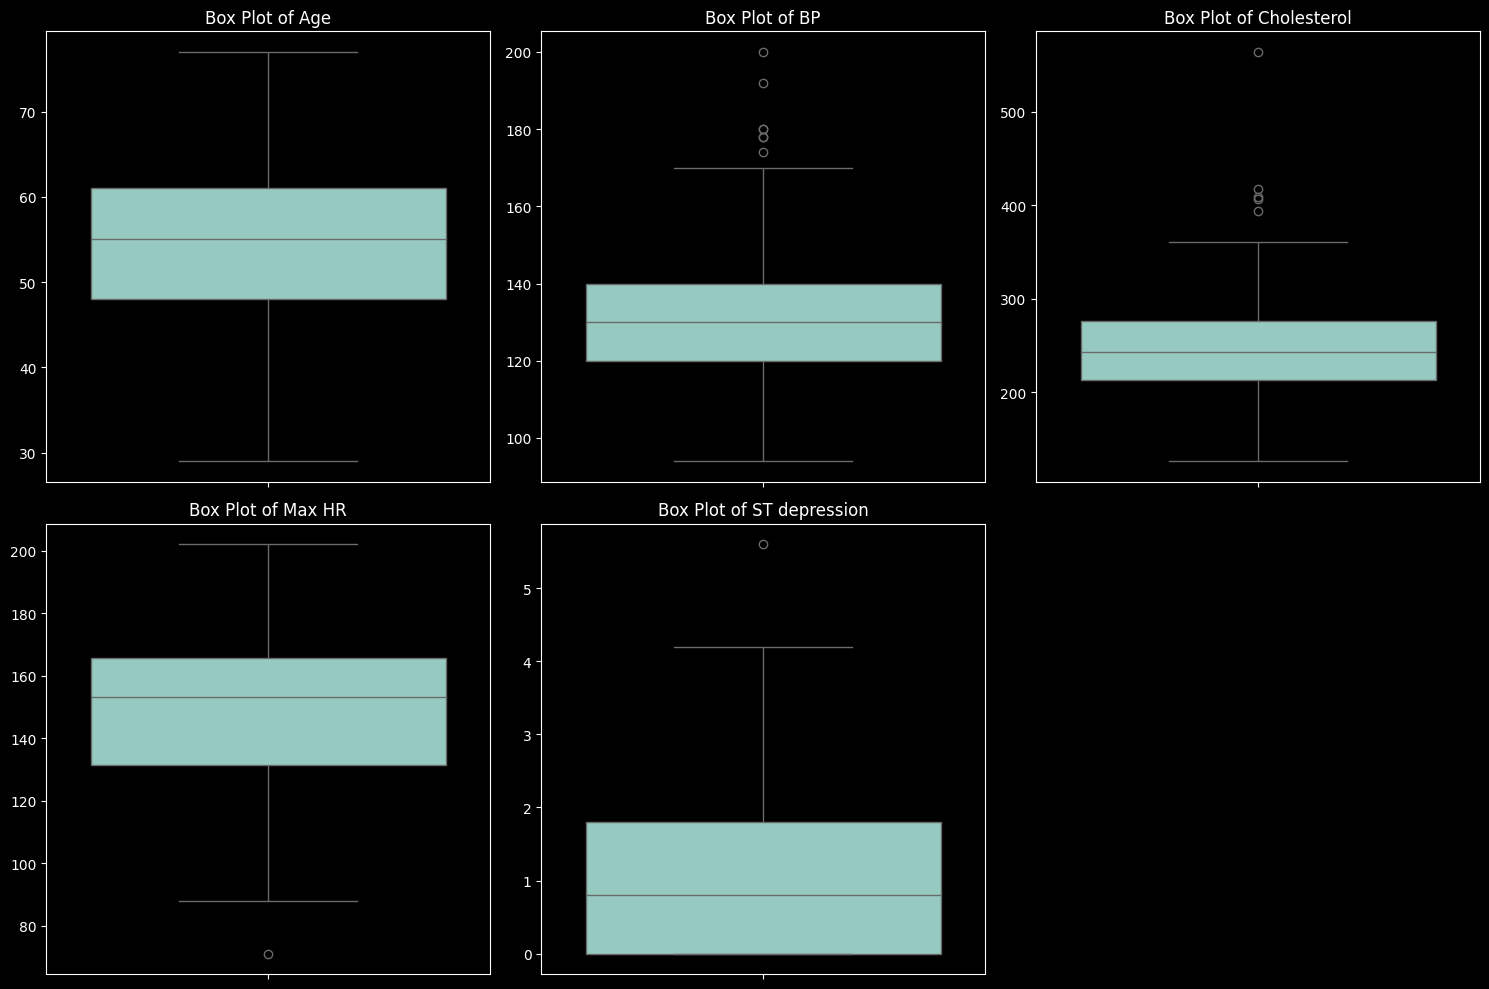

In [213]:
numerical_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=X_train[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

**Identifying Outlier Indices using IQR**

In [214]:
outlier_indices = {}
for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    col_outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)].index.tolist()
    outlier_indices[col] = col_outliers

    print(f"Column: {col}")
    print(f"  Number of outliers: {len(col_outliers)}")
    print(f"  Outlier indices: {col_outliers}\n")

Column: Age
  Number of outliers: 0
  Outlier indices: []

Column: BP
  Number of outliers: 7
  Outlier indices: [58, 87, 110, 117, 153, 168, 174]

Column: Cholesterol
  Number of outliers: 5
  Outlier indices: [1, 9, 52, 190, 197]

Column: Max HR
  Number of outliers: 1
  Outlier indices: [101]

Column: ST depression
  Number of outliers: 1
  Outlier indices: [165]



**Capping Outliers using IQR**

In [215]:
for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers in X_train
    X_train[col] = X_train[col].clip(lower=lower_bound, upper=upper_bound)

    # Cap outliers in X_test using bounds from X_train
    X_test[col] = X_test[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers capped successfully in X_train and X_test.")

display(X_train.head())
display(X_test.head())

Outliers capped successfully in X_train and X_test.


,Age,Gender,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Number of vessels fluro,smoking_status_Unknown,...,Chest pain type_4,Slope of ST_1,Slope of ST_2,Slope of ST_3,EKG results_0,EKG results_1,EKG results_2,Thallium_3,Thallium_6,Thallium_7
0,70.0,0,130,322.00,0,109.0,0,2.4,3,0,...,1,0,1,0,0,0,1,1,0,0
1,67.0,1,115,371.75,0,160.0,0,1.6,0,0,...,0,0,1,0,0,0,1,0,0,1
2,57.0,0,124,261.00,0,141.0,0,0.3,0,0,...,0,1,0,0,1,0,0,0,0,1
3,64.0,0,128,263.00,0,105.0,1,0.2,1,0,...,1,0,1,0,1,0,0,0,0,1
4,74.0,1,120,269.00,0,121.0,1,0.2,1,0,...,0,1,0,0,0,0,1,1,0,0


,Age,Gender,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Number of vessels fluro,smoking_status_Unknown,...,Chest pain type_4,Slope of ST_1,Slope of ST_2,Slope of ST_3,EKG results_0,EKG results_1,EKG results_2,Thallium_3,Thallium_6,Thallium_7
0,41.0,1,130,204,0,172,0,1.4,0,0,...,0,1,0,0,0,0,1,1,0,0
1,63.0,1,135,252,0,172,0,0.0,0,0,...,0,1,0,0,0,0,1,1,0,0
2,51.0,0,94,227,0,154,1,0.0,1,0,...,0,1,0,0,1,0,0,0,0,1
3,54.0,0,120,258,0,147,0,0.4,0,0,...,0,0,1,0,0,0,1,0,0,1
4,44.0,0,120,220,0,170,0,0.0,0,0,...,0,1,0,0,1,0,0,1,0,0


**Visualizing Outliers after Capping with Box Plots**

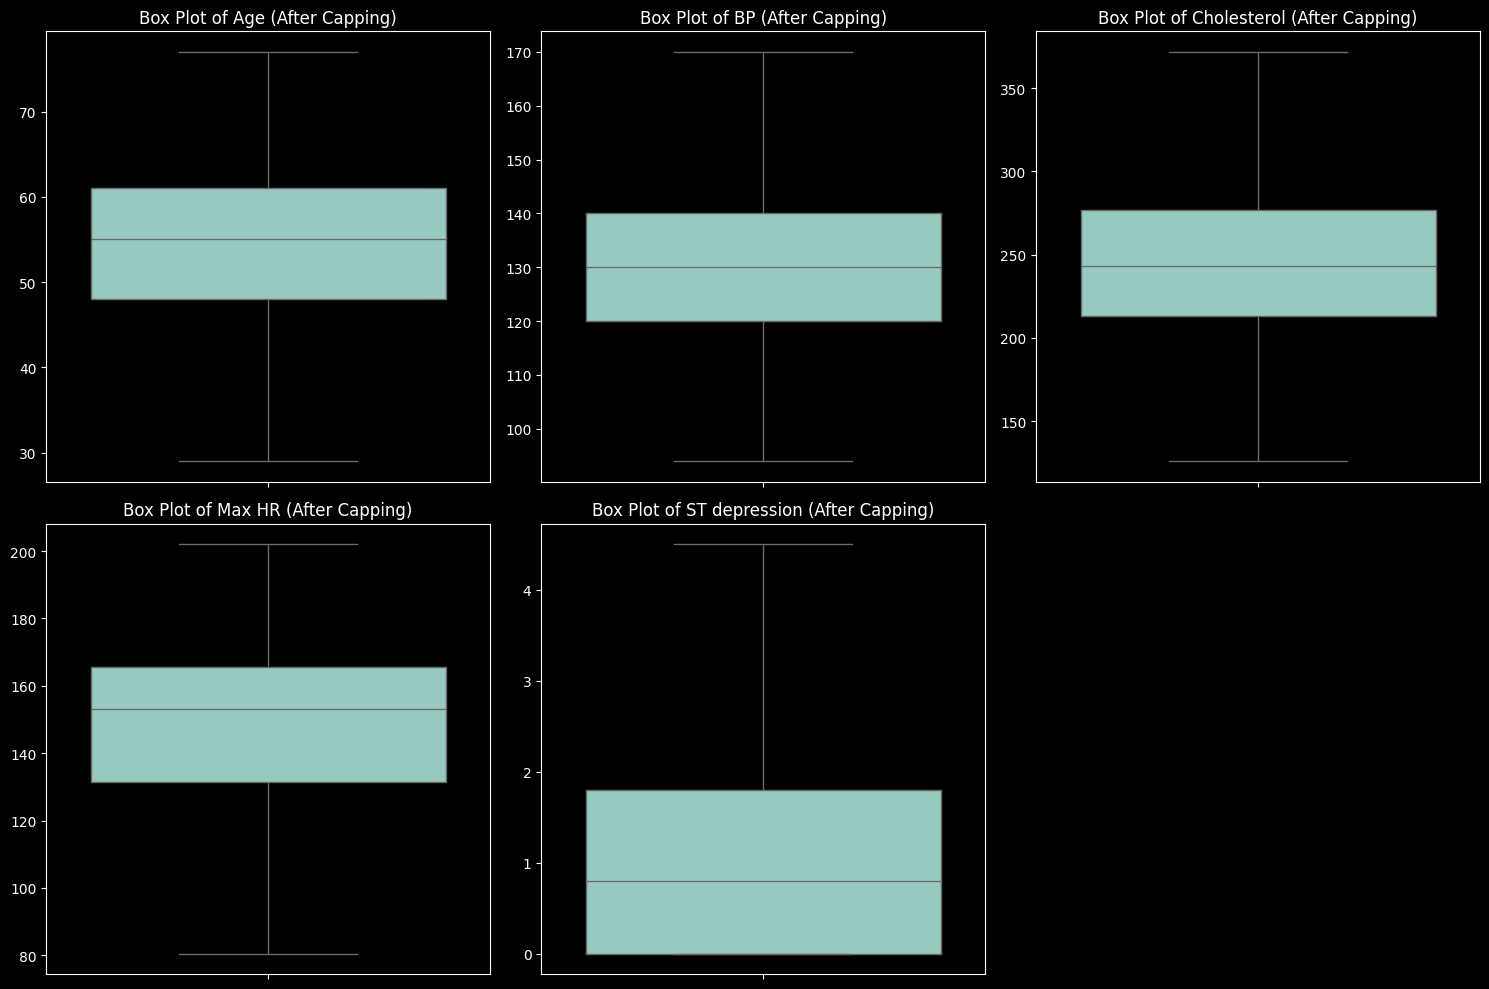

In [216]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=X_train[col])
    plt.title(f'Box Plot of {col} (After Capping)')
    plt.ylabel('')
plt.tight_layout()
plt.show()

**Scaling Numerical Features**

In [217]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train = X_train_scaled
X_test = X_test_scaled
# scaler = StandardScaler()
# X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
# X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])
# display(X_train.head())

# Logistic Regression

In [ ]:

model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:


y_pred = model.predict(X_test_scaled)
print("ress")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred):.4f}")

ress
  Accuracy  : 0.8909
  Precision : 0.9500
  Recall    : 0.7917
  F1-Score  : 0.8636


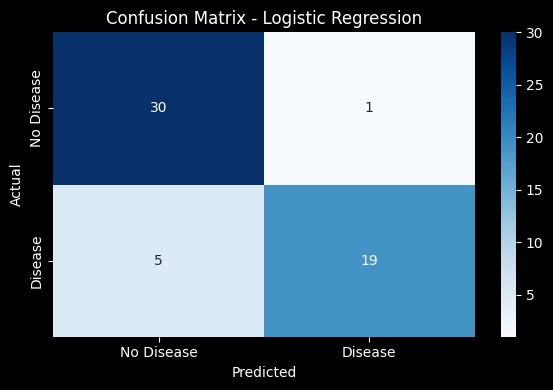

In [ ]:


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
          xticklabels=['No Disease', 'Disease'],
          yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:

results = []

C_values = [0.01, 0.1, 1, 10, 100]
iter_values = [100, 500, 1000]

for c in C_values:
    for it in iter_values:
        m = LogisticRegression(C=c, max_iter=it, random_state=42)
        m.fit(X_train_scaled, y_train)
        pred = m.predict(X_test_scaled)
        results.append({
            'C': c,
            'max_iter': it,
            'Accuracy': round(accuracy_score(y_test, pred), 4),
            'Recall': round(recall_score(y_test, pred), 4),
            'F1': round(f1_score(y_test, pred), 4)
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best = results_df.loc[results_df['F1'].idxmax()]
print(f"\nbest C={best['C']}, max_iter={best['max_iter']}, F1={best['F1']}")

     C  max_iter  Accuracy  Recall     F1
  0.01       100    0.8364  0.7500 0.8000
  0.01       500    0.8364  0.7500 0.8000
  0.01      1000    0.8364  0.7500 0.8000
  0.10       100    0.8727  0.7917 0.8444
  0.10       500    0.8727  0.7917 0.8444
  0.10      1000    0.8727  0.7917 0.8444
  1.00       100    0.8909  0.7917 0.8636
  1.00       500    0.8909  0.7917 0.8636
  1.00      1000    0.8909  0.7917 0.8636
 10.00       100    0.8727  0.7500 0.8372
 10.00       500    0.8727  0.7500 0.8372
 10.00      1000    0.8727  0.7500 0.8372
100.00       100    0.8727  0.7500 0.8372
100.00       500    0.8727  0.7500 0.8372
100.00      1000    0.8727  0.7500 0.8372

best C=1.0, max_iter=100.0, F1=0.8636


# Descission Tree without GridSearchCV

 max_depth criterion  Accuracy  Precision  Recall     F1
       3.0      gini    0.8545     0.8636  0.7917 0.8261
       3.0   entropy    0.8545     0.8636  0.7917 0.8261
       5.0      gini    0.8000     0.7826  0.7500 0.7660
       5.0   entropy    0.7636     0.7391  0.7083 0.7234
       7.0      gini    0.8000     0.7600  0.7917 0.7755
       7.0   entropy    0.7636     0.7200  0.7500 0.7347
      10.0      gini    0.8000     0.7600  0.7917 0.7755
      10.0   entropy    0.7636     0.7200  0.7500 0.7347
       NaN      gini    0.8000     0.7600  0.7917 0.7755
       NaN   entropy    0.7636     0.7200  0.7500 0.7347
  Precision : 0.7200
  Recall    : 0.7500
  F1-Score  : 0.7347

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.77      0.79        31
     Disease       0.72      0.75      0.73        24

    accuracy                           0.76        55
   macro avg       0.76      0.76      0.76        55
weighted avg  

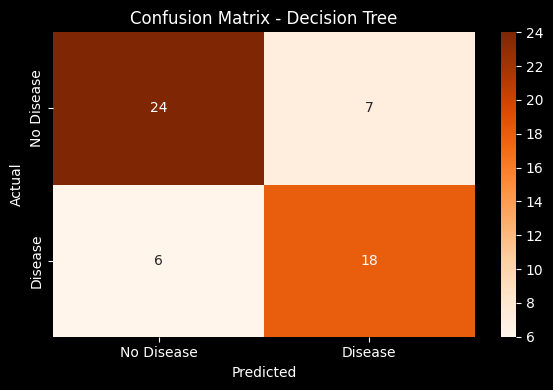

In [223]:
results_dt = []
for depth in [3, 5, 7, 10, None]:
    for crit in ['gini', 'entropy']:
        dt = DecisionTreeClassifier(max_depth=depth, criterion=crit, random_state=42)
        dt.fit(X_train_scaled, y_train)
        pred = dt.predict(X_test_scaled)
        results_dt.append({'max_depth': depth, 'criterion': crit,
            'Accuracy': round(accuracy_score(y_test, pred), 4),
            'Precision': round(precision_score(y_test, pred), 4),
            'Recall': round(recall_score(y_test, pred), 4),
            'F1': round(f1_score(y_test, pred), 4)})
print(pd.DataFrame(results_dt).to_string(index=False))

decision_tree_model = DecisionTreeClassifier(criterion = "entropy", random_state = 42)
decision_tree_model.fit(X_train_scaled, y_train)
y_predicted_by_decision_tree = decision_tree_model.predict(X_test_scaled)

accuracy_of_decision_tree = accuracy_score(y_test, y_predicted_by_decision_tree)
print(f"  Precision : {precision_score(y_test, y_predicted_by_decision_tree):.4f}")
print(f"  Recall    : {recall_score(y_test, y_predicted_by_decision_tree):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_predicted_by_decision_tree):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_predicted_by_decision_tree, target_names=['No Disease', 'Disease']))
print("Accuracy of decision tree model:", accuracy_of_decision_tree)
cm_dt = confusion_matrix(y_test, y_predicted_by_decision_tree)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('tree_cm.png', bbox_inches='tight', dpi=300)
plt.show()


# Descission Tree with GridSearchCV

In [224]:
# Define different combinations that will be tried in grid search
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 8, 10, 12, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 15, 20, 25, 30],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10, 15],
}

# Define how to do grid search
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Actually do grid search
grid_search.fit(X_train_scaled, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)

Fitting 5 folds for each of 980 candidates, totalling 4900 fits
Best parameters found:  {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best cross-validation accuracy:  0.813953488372093


In [225]:
decision_tree_model = grid_search.best_estimator_

y_predicted_by_decision_tree = decision_tree_model.predict(X_test_scaled)

In [226]:
accuracy_of_decision_tree = accuracy_score(y_test, y_predicted_by_decision_tree)
f1_score_of_decision_tree = f1_score(y_test, y_predicted_by_decision_tree)

print("Accuracy of best Decision Tree model: ", accuracy_of_decision_tree)
print("F1 score of best Decision Tree model: ", f1_score_of_decision_tree)

Accuracy of best Decision Tree model:  0.8545454545454545
F1 score of best Decision Tree model:  0.8260869565217391


In [227]:
decision_tree_model.fit(X_train, y_train)
y_predicted_by_decision_tree = decision_tree_model.predict(X_test)

In [228]:
accuracy_of_decision_tree = accuracy_score(y_test, y_predicted_by_decision_tree)
print("Accuracy of decision tree model: ", accuracy_of_decision_tree)

f1_score_of_decision_tree = f1_score(y_test, y_predicted_by_decision_tree)
print("F1 score of decision tree model: ", f1_score_of_decision_tree)

Accuracy of decision tree model:  0.8545454545454545
F1 score of decision tree model:  0.8260869565217391


**SVM without using a grid search**

In [230]:
plt.style.use('dark_background')

# just picking randomly here until we do a grid search
svm_model = SVC(kernel='linear', C=0.1, random_state=42)

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
accuracy_of_svm = accuracy_score(y_test, y_pred_svm)

labels = ['Negative', 'Positive']

print("--- SVM Model Evaluation ---")
print("Accuracy: ", f"{accuracy_of_svm:.3f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=labels))

--- SVM Model Evaluation ---
Accuracy:  0.800
Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.84      0.83        31
    Positive       0.78      0.75      0.77        24

    accuracy                           0.80        55
   macro avg       0.80      0.79      0.80        55
weighted avg       0.80      0.80      0.80        55



**SVM Confusion Matrix Without Using Grid Search**

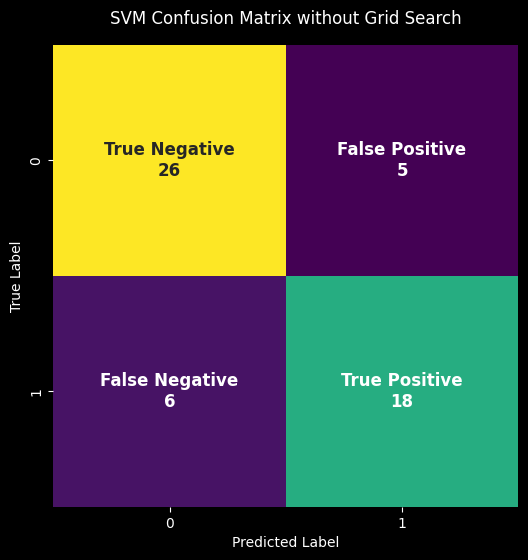

In [231]:
cm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)

group_names = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
group_counts = [str(value) for value in cm.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2, 2)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='viridis', cbar=False,
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_,
            ax=ax, annot_kws={"size": 12, "weight": "bold"})

plt.title("SVM Confusion Matrix without Grid Search", pad=15)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**SVM Grid Search**

In [232]:
# we use an algorithm called grid search to find the optimal values for our hyperparameters
# instead of just picking them randomly like i did above

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'] # added gamma to give the rbf/poly kernels more tuning options
}

svm_base = SVC(random_state=42)

svm_grid = GridSearchCV(estimator=svm_base, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# cv = 5 means we are doing 5-fold cross-validation
# n_jobs=-1 means we are using all available CPU cores to speed up the search process

**SVM using a Grid Search**

In [233]:
svm_grid.fit(X_train, y_train)
y_pred_grid_search_svm = svm_grid.predict(X_test)
accuracy_of_grid_search_svm = accuracy_score(y_test, y_pred_grid_search_svm)
best_svm = svm_grid.best_estimator_

labels = ['Negative', 'Positive']

print("--- SVM Model Evaluation ---")
print("Best Hyperparameters Found:", svm_grid.best_params_)
print("Best Cross-Validation Accuracy: ", f"{accuracy_of_grid_search_svm:.3f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_grid_search_svm, target_names=labels))

--- SVM Model Evaluation ---
Best Hyperparameters Found: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Accuracy:  0.855
Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.90      0.88        31
    Positive       0.86      0.79      0.83        24

    accuracy                           0.85        55
   macro avg       0.86      0.85      0.85        55
weighted avg       0.86      0.85      0.85        55



**SVM Confusion Matrix using Grid Serach**

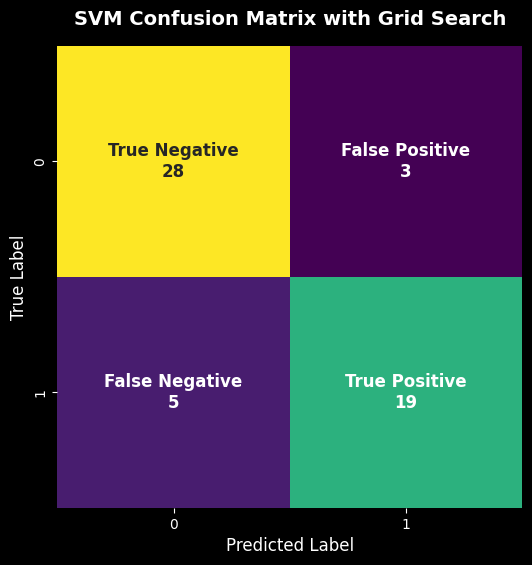

In [234]:
plt.style.use('dark_background')

cm = confusion_matrix(y_test, y_pred_grid_search_svm, labels=best_svm.classes_)

group_names = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
group_counts = [str(value) for value in cm.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2, 2)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='viridis', cbar=False,
            xticklabels=best_svm.classes_, yticklabels=best_svm.classes_,
            ax=ax, annot_kws={"size": 12, "weight": "bold"})

plt.title("SVM Confusion Matrix with Grid Search", pad=15, fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# Random Forest Model Evaluation


In [ ]:

param_grid = {
    'n_estimators': [50, 65, 75, 100, ],
    'max_depth': [5, 10, 15, None]
}
rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1 # Prints progress
)

print("Starting Grid Search... This might take a minute!")
grid_search.fit(X_train_scaled, y_train)
best_rf_model = grid_search.best_estimator_
print(f"\nBest Parameters Found: {grid_search.best_params_}")

# Evaluate the best model on the unseen test set
y_pred_rf = best_rf_model.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("\n--- Best Random Forest Model Evaluation ---")
print(f"Accuracy  : {accuracy_rf:.3f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Disease']))

Starting Grid Search... This might take a minute!
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters Found: {'max_depth': 5, 'n_estimators': 75}

--- Best Random Forest Model Evaluation ---
Accuracy  : 0.891
Precision : 0.9500
Recall    : 0.7917
F1-Score  : 0.8636

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.86      0.97      0.91        31
     Disease       0.95      0.79      0.86        24

    accuracy                           0.89        55
   macro avg       0.90      0.88      0.89        55
weighted avg       0.90      0.89      0.89        55



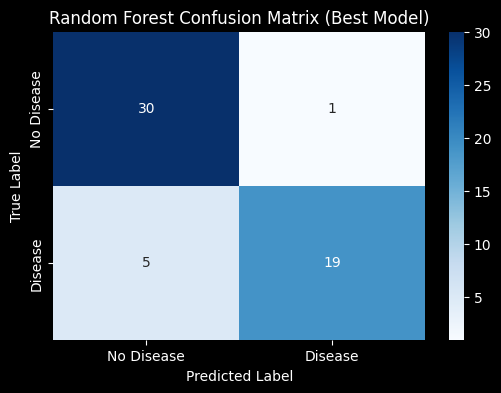


Grid Search Results Summary:
 n_estimators max_depth  CV_Accuracy
           75         5     0.851163
           65         5     0.832558
          100         5     0.832558
           50         5     0.827907
           50        10     0.818605
           50        15     0.818605
           50      None     0.818605
           65      None     0.813953
           65        15     0.813953
           75      None     0.809302
           75        15     0.809302
           65        10     0.804651
           75        10     0.800000
          100        15     0.795349
          100      None     0.795349


In [236]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title("Random Forest Confusion Matrix (Best Model)")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('random_cm.png', bbox_inches='tight', dpi=300)
plt.show()


cv_results_df = pd.DataFrame(grid_search.cv_results_)

# Filter to show the columns you care about to match your original output
display_cols = ['param_n_estimators', 'param_max_depth', 'mean_test_score']
results_summary = cv_results_df[display_cols].copy()
results_summary.rename(columns={
    'param_n_estimators': 'n_estimators',
    'param_max_depth': 'max_depth',
    'mean_test_score': 'CV_Accuracy'
}, inplace=True)

# Sort by the best accuracy
results_summary = results_summary.sort_values(by='CV_Accuracy', ascending=False)

print("\nGrid Search Results Summary:")
print(results_summary.head(15).to_string(index=False)) # Showing top 15 results

# K-Nearest Neighbors (KNN) Model Evaluation


In [ ]:

param_grid_knn = {
    'n_neighbors': range(20, 70), # Tests every integer from 20 to 69
    'weights': ['uniform', 'distance']
}
knn_base = KNeighborsClassifier()
grid_search_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1 # Prints progress
)
print("Starting KNN Grid Search... This will test 100 combinations!")
grid_search_knn.fit(X_train_scaled, y_train)

# 4. Extract the best model
best_knn_model = grid_search_knn.best_estimator_
print(f"\nBest Parameters Found: {grid_search_knn.best_params_}")

# 5. Evaluate the best model on the unseen test set
y_pred_knn = best_knn_model.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("\n--- Best K-Nearest Neighbors Model Evaluation ---")
print(f"Accuracy  : {accuracy_knn:.3f}")
print(f"Precision : {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_knn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['No Disease', 'Disease']))


Starting KNN Grid Search... This will test 100 combinations!
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Parameters Found: {'n_neighbors': 36, 'weights': 'uniform'}

--- Best K-Nearest Neighbors Model Evaluation ---
Accuracy  : 0.873
Precision : 0.9048
Recall    : 0.7917
F1-Score  : 0.8444

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.85      0.94      0.89        31
     Disease       0.90      0.79      0.84        24

    accuracy                           0.87        55
   macro avg       0.88      0.86      0.87        55
weighted avg       0.88      0.87      0.87        55



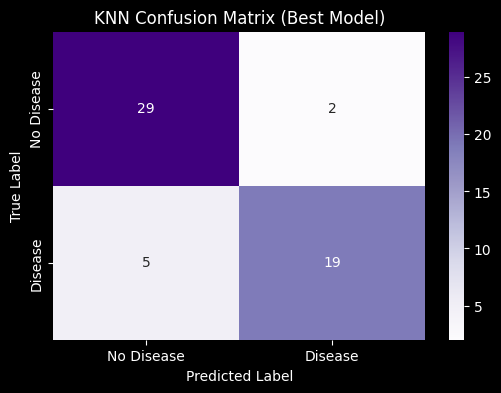


KNN Grid Search Results Summary (Top 15):
 n_neighbors  weights  CV_Accuracy
          36  uniform     0.855814
          42  uniform     0.851163
          42 distance     0.851163
          43  uniform     0.851163
          47 distance     0.851163
          47  uniform     0.851163
          49  uniform     0.851163
          35 distance     0.846512
          35  uniform     0.846512
          53 distance     0.846512
          51  uniform     0.846512
          51 distance     0.846512
          38  uniform     0.846512
          43 distance     0.846512
          39 distance     0.846512


In [238]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title("KNN Confusion Matrix (Best Model)")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('knn_cm.png', bbox_inches='tight', dpi=300)
plt.show()

# 7. Recreate your results DataFrame
# Extract the results to match your original output
cv_results_knn_df = pd.DataFrame(grid_search_knn.cv_results_)

display_cols_knn = ['param_n_neighbors', 'param_weights', 'mean_test_score']
results_summary_knn = cv_results_knn_df[display_cols_knn].copy()
results_summary_knn.rename(columns={
    'param_n_neighbors': 'n_neighbors',
    'param_weights': 'weights',
    'mean_test_score': 'CV_Accuracy'
}, inplace=True)

# Sort by the best accuracy
results_summary_knn = results_summary_knn.sort_values(by='CV_Accuracy', ascending=False)

print("\nKNN Grid Search Results Summary (Top 15):")
print(results_summary_knn.head(15).to_string(index=False))

 # Gradient Boosting Model Evaluation


In [ ]:

param_grid_gb = {
    'n_estimators': [50, 65, 75, 85, 100, 200, 300],
    'learning_rate': [0.01, 0.02, 0.1]
}


gb_base = GradientBoostingClassifier(random_state=42)


grid_search_gb = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid_gb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1 # Prints progress
)

print("Starting Gradient Boosting Grid Search... Testing 21 combinations!")
grid_search_gb.fit(X_train_scaled, y_train)

best_gb_model = grid_search_gb.best_estimator_
print(f"\nBest Parameters Found: {grid_search_gb.best_params_}")

y_pred_gb = best_gb_model.predict(X_test_scaled)
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("\n--- Best Gradient Boosting Model Evaluation ---")
print(f"Accuracy  : {accuracy_gb:.3f}")
print(f"Precision : {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_gb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, target_names=['No Disease', 'Disease']))

Starting Gradient Boosting Grid Search... Testing 21 combinations!
Fitting 5 folds for each of 21 candidates, totalling 105 fits

Best Parameters Found: {'learning_rate': 0.01, 'n_estimators': 50}

--- Best Gradient Boosting Model Evaluation ---
Accuracy  : 0.873
Precision : 0.9048
Recall    : 0.7917
F1-Score  : 0.8444

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.85      0.94      0.89        31
     Disease       0.90      0.79      0.84        24

    accuracy                           0.87        55
   macro avg       0.88      0.86      0.87        55
weighted avg       0.88      0.87      0.87        55



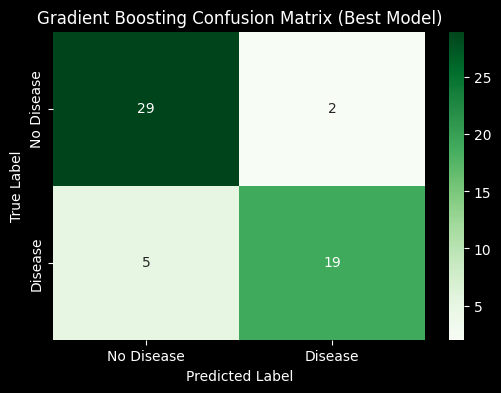


Gradient Boosting Grid Search Results Summary:
 n_estimators  learning_rate  CV_Accuracy
           50           0.01     0.786047
           65           0.01     0.786047
          200           0.01     0.781395
          100           0.02     0.781395
          300           0.01     0.781395
          300           0.02     0.781395
           65           0.10     0.776744
           75           0.01     0.776744
           85           0.01     0.776744
           85           0.02     0.776744
          200           0.02     0.776744
           50           0.10     0.776744
           75           0.02     0.776744
           75           0.10     0.776744
           50           0.02     0.772093


In [240]:
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title("Gradient Boosting Confusion Matrix (Best Model)")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('gb_cm.png', bbox_inches='tight', dpi=300)
plt.show()

cv_results_gb_df = pd.DataFrame(grid_search_gb.cv_results_)

display_cols_gb = ['param_n_estimators', 'param_learning_rate', 'mean_test_score']
results_summary_gb = cv_results_gb_df[display_cols_gb].copy()
results_summary_gb.rename(columns={
    'param_n_estimators': 'n_estimators',
    'param_learning_rate': 'learning_rate',
    'mean_test_score': 'CV_Accuracy'
}, inplace=True)

results_summary_gb = results_summary_gb.sort_values(by='CV_Accuracy', ascending=False)

print("\nGradient Boosting Grid Search Results Summary:")
print(results_summary_gb.head(15).to_string(index=False))

In [243]:
import joblib
import os

# Ensure the assets directory exists
os.makedirs('./assets', exist_ok=True)

# 1. Extract the Logistic Regression Model
# (Using the base 'model' variable from your code)
joblib.dump(model, './assets/logistic_regression.pkl')

# 2. Extract the Decision Tree Model
joblib.dump(decision_tree_model, './assets/decision_tree.pkl')

# 3. Extract the Best SVM Model
joblib.dump(best_svm, './assets/svm_model.pkl')

# 4. Extract the Best Gradient Boosting Model (FIXED)
joblib.dump(best_gb_model, './assets/gb_model.pkl')

# 5. Extract the Best KNN Model (FIXED)
joblib.dump(best_knn_model, './assets/knn_model.pkl')

# 6. Extract the Best Random Forest Model (FIXED)
joblib.dump(best_rf_model, './assets/rf_model.pkl')

# 7. Extract the Scaler
joblib.dump(scaler, './assets/scaler.pkl')

print("✅ All models and the scaler have been successfully extracted!")

✅ All models and the scaler have been successfully extracted!


In [242]:
%pip install pandas==2.2.2